In [2]:
import os
import pickle 
from transformers import pipeline
import torch.nn.functional as F
from torch import cuda, bfloat16
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import BitsAndBytesConfig
from matplotlib import pyplot as plt

In [3]:
API_KEY = ''

In [4]:
cuda.is_available()

True

In [5]:
model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B-Instruct", 
                                             token=API_KEY,
                                             cache_dir = '/data_users1/sagar')
model = model.to('cuda')

In [6]:
type(model)

transformers.models.llama.modeling_llama.LlamaForCausalLM

In [58]:
with open('../data/processed/winograd_pairs.pkl', 'rb') as f:
    sentences = pickle.load(f)

test_sent = sentences.get(16)
#test_sent['template'] = test_sent['template'].replace('BLANK', '[BLANK]')
test_sent

{'differences': ['he', 'she'],
 'template': 'The homeowner asked the inspector if the house BLANK had purchased was structurally sound.',
 'referent': 'homeowner'}

In [59]:
sentence = test_sent['template']
options = test_sent['differences']

In [60]:
sentence.split('BLANK')[0][:-1]

'The homeowner asked the inspector if the house'

In [68]:
options = options[::-1]
messages=[
        {
            "role": "system",
            "content":("Below you will find a passage in *bold* which contains precisely one instance of "
                       f"the token BLANK. You will also be provided two options. "
                       "Your task is to replace the BLANK token with one of the options provided. "
                       "The tasks are designed to be unambiguous, so please provide only one solution and "
                       "do not reorder the data.")
        },
        {
            "role": "user",
            "content": (f"Given this passage: *{sentence}*\n"
                        f"Replace the BLANK  with one of the following options: {options}")
        },
    {
        "role": "assistant",
        "content": sentence.split('BLANK')[0][:-1]
    }
    ]

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B-Instruct", token=API_KEY)

#tokenizer.chat_template = (
#    "{% for message in messages %}"
#    "{% if message['role'] == 'system' %}"
#    "<<SYS>>\n{{ message['content'] }}\n<</SYS>>\n\n"
#    "{% elif message['role'] == 'user' %}"
#    "[INST] {{ message['content'] }} [/INST]"
#    "{% elif message['role'] == 'assistant' %}"
#    "{{ message['content'] }}\n"
#    "{% endif %}"
#    "{% endfor %}"
#)
#tokenizer.chat_template = test_chat_template

inputs = tokenizer.apply_chat_template(messages, return_tensors="pt", continue_final_message=True).to("cuda:0")

outputs = model.generate(inputs, 
                         max_new_tokens = 6,
                         output_scores=True, 
                         return_dict_in_generate=True, 
                         output_hidden_states=True, 
                         do_sample = True, 
                         temperature = 0.5, 
                         pad_token_id=tokenizer.eos_token_id,
                        top_k=2)

#print(completion.choices[0].message)

In [69]:
type(outputs)

transformers.generation.utils.GenerateDecoderOnlyOutput

In [70]:
decoded_output = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True)

In [71]:
decoded_output

"system\n\nCutting Knowledge Date: December 2023\nToday Date: 14 Jul 2025\n\nBelow you will find a passage in *bold* which contains precisely one instance of the token BLANK. You will also be provided two options. Your task is to replace the BLANK token with one of the options provided. The tasks are designed to be unambiguous, so please provide only one solution and do not reorder the data.user\n\nGiven this passage: *The homeowner asked the inspector if the house BLANK had purchased was structurally sound.*\nReplace the BLANK  with one of the following options: ['she', 'he']assistant\n\nThe homeowner asked the inspector if the house she had purchased was structurally"

In [72]:
input_length = inputs.shape[1]  # Number of tokens in the input prompt
generated_tokens = outputs.sequences[0][input_length:]  # Only new tokens

# Decode just the assistant's response
assistant_reply = tokenizer.decode(generated_tokens, skip_special_tokens=True)
assistant_reply

' she had purchased was structurally'

In [73]:
outputs.scores

(tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
 tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
 tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
 tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
 tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
 tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'))

In [74]:
# Step 3: Get scores (logits for each generated token)
scores = outputs.scores  # List of length = max_new_tokens

token_probs = []

for token_id, score in zip(generated_tokens, outputs.scores):
    if score.dim() == 2:
        score = score[0]  # from shape [1, vocab_size] to [vocab_size]
    
    probs = F.softmax(score, dim=-1)
    prob = probs[token_id].item()
    token = tokenizer.convert_ids_to_tokens(int(token_id))
    token_probs.append((token, prob))

# Display
for token, prob in token_probs:
    print(f"{token}\t{prob:.4f}")


Ġshe	0.4595
Ġhad	1.0000
Ġpurchased	1.0000
Ġwas	1.0000
Ġstruct	1.0000
urally	1.0000


In [81]:
outputs.scores[0][0,tokenizer.convert_tokens_to_ids(tokenizer.tokenize(" he"))[0]]

tensor(-inf, device='cuda:0')

In [82]:
outputs.scores[0][0,tokenizer.convert_tokens_to_ids(tokenizer.tokenize(" she"))[0]]

tensor(38.2134, device='cuda:0')

In [16]:
# Step 6: Token IDs for candidate completions
candidates = [" his", " her"]  # NOTE: leading space matters for most tokenizers
candidate_ids = (tokenizer.convert_tokens_to_ids(tokenizer.tokenize(candidates[0])), 
                 tokenizer.convert_tokens_to_ids(tokenizer.tokenize(candidates[1])))

# Handle multi-token candidates
for label, ids in zip(candidates, candidate_ids):
    if len(ids) > 1:
        print(f"'{label}' is multi-token: {ids} – this will require joint probability.")
    else:
        prob = probs[ids[0]].item()
        print(f"P({label}) = {prob:.4f}")

P( his) = 0.0000
P( her) = 0.0000


In [147]:
tokenizer.convert_tokens_to_ids(tokenizer.tokenize(candidates[0]))

[813]

In [148]:
for _id, score in zip(generated_tokens, outputs.scores):
    if _id == 813:
        print(F.softmax(score, dim=-1))

In [149]:
generated_tokens

tensor([ 1077,  4477,  7512,   627, 23979,   279], device='cuda:0')

In [150]:
tokenizer.convert_ids_to_tokens(813)

'Ġhis'

## Trying a different way

In [151]:
input_dict = {'input_ids': inputs}
with torch.no_grad():
    outputs_simple = model(**input_dict)

In [179]:
model(**input_dict) 

CausalLMOutputWithPast(loss=None, logits=tensor([[[ 7.0544,  9.0268, 13.3233,  ..., -3.7595, -3.7596, -3.7596],
         [11.3817, 12.3789, 12.6324,  ...,  2.4516,  2.4514,  2.4514],
         [12.0009, 13.1161, 12.9221,  ...,  2.3625,  2.3622,  2.3620],
         ...,
         [10.9696,  9.9965,  9.0516,  ...,  2.8615,  2.8611,  2.8614],
         [11.1491, 10.1212,  9.2570,  ...,  0.9393,  0.9395,  0.9397],
         [ 9.6038,  9.4315,  8.1888,  ...,  1.5949,  1.5945,  1.5949]]],
       device='cuda:0', grad_fn=<UnsafeViewBackward0>), past_key_values=<transformers.cache_utils.DynamicCache object at 0x7effc929ef10>, hidden_states=None, attentions=None)

In [176]:
model(inputs)

CausalLMOutputWithPast(loss=None, logits=tensor([[[ 7.0544,  9.0268, 13.3233,  ..., -3.7595, -3.7596, -3.7596],
         [11.3817, 12.3789, 12.6324,  ...,  2.4516,  2.4514,  2.4514],
         [12.0009, 13.1161, 12.9221,  ...,  2.3625,  2.3622,  2.3620],
         ...,
         [10.9696,  9.9965,  9.0516,  ...,  2.8615,  2.8611,  2.8614],
         [11.1491, 10.1212,  9.2570,  ...,  0.9393,  0.9395,  0.9397],
         [ 9.6038,  9.4315,  8.1888,  ...,  1.5949,  1.5945,  1.5949]]],
       device='cuda:0', grad_fn=<UnsafeViewBackward0>), past_key_values=<transformers.cache_utils.DynamicCache object at 0x7effc9b9b450>, hidden_states=None, attentions=None)

In [152]:
logits = outputs_simple.logits

In [153]:
logits

tensor([[[ 7.0544,  9.0268, 13.3233,  ..., -3.7595, -3.7596, -3.7596],
         [11.3817, 12.3789, 12.6324,  ...,  2.4516,  2.4514,  2.4514],
         [12.0009, 13.1161, 12.9221,  ...,  2.3625,  2.3622,  2.3620],
         ...,
         [10.9696,  9.9965,  9.0516,  ...,  2.8615,  2.8611,  2.8614],
         [11.1491, 10.1212,  9.2570,  ...,  0.9393,  0.9395,  0.9397],
         [ 9.6038,  9.4315,  8.1888,  ...,  1.5949,  1.5945,  1.5949]]],
       device='cuda:0')

In [154]:
next_token_logits = logits[0, -1]

In [155]:
next_token_logits

tensor([9.6038, 9.4315, 8.1888,  ..., 1.5949, 1.5945, 1.5949], device='cuda:0')

In [156]:
probs = F.softmax(next_token_logits, dim=-1)

In [157]:
option1 = " his"
option2 = " her"

ids1 = tokenizer.encode(option1, add_special_tokens=False)
ids2 = tokenizer.encode(option2, add_special_tokens=False)

In [158]:
prob1 = probs[ids1[0]].item()
prob2 = probs[ids2[0]].item()
prob1, prob2

(0.02018204890191555, 0.3264949321746826)

In [159]:
probs

tensor([4.9836e-06, 4.1949e-06, 1.2106e-06,  ..., 1.6569e-09, 1.6563e-09,
        1.6569e-09], device='cuda:0')

In [160]:
# shape is (batch_size, sequence_length, vocab size)
outputs_simple.logits

tensor([[[ 7.0544,  9.0268, 13.3233,  ..., -3.7595, -3.7596, -3.7596],
         [11.3817, 12.3789, 12.6324,  ...,  2.4516,  2.4514,  2.4514],
         [12.0009, 13.1161, 12.9221,  ...,  2.3625,  2.3622,  2.3620],
         ...,
         [10.9696,  9.9965,  9.0516,  ...,  2.8615,  2.8611,  2.8614],
         [11.1491, 10.1212,  9.2570,  ...,  0.9393,  0.9395,  0.9397],
         [ 9.6038,  9.4315,  8.1888,  ...,  1.5949,  1.5945,  1.5949]]],
       device='cuda:0')

In [161]:
type(outputs_simple)

transformers.modeling_outputs.CausalLMOutputWithPast

In [162]:
test_tensor = torch.tensor([[[0, 1, 2], [3, 4, 5]], [[6, 7, 8], [9, 10, 11]]])

In [163]:
test_tensor

tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]]])

In [164]:
test_tensor[0, -1]

tensor([3, 4, 5])

In [165]:
# in this case, batch_size = 1 so arr[0, -1] is the probs for all tokens in the input so the 
# output of the last token is predictions of the next one
outputs_simple.logits.shape

torch.Size([1, 148, 128256])

In [166]:
torch.argmax(probs) # <- this corresponds to " his"

tensor(1077, device='cuda:0')

In [167]:
probs

tensor([4.9836e-06, 4.1949e-06, 1.2106e-06,  ..., 1.6569e-09, 1.6563e-09,
        1.6569e-09], device='cuda:0')

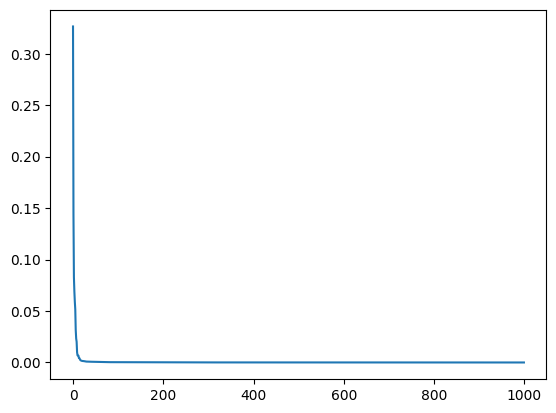

In [168]:
# Very sharp
probs_cpu = probs.squeeze().detach().cpu()  # shape: (128256,)
k = 1000
topk_probs, topk_indices = torch.topk(probs_cpu, k)
plt.plot(range(k), topk_probs)

In [169]:
# how many have p > .01
len(probs[probs > 0.01])

9

In [127]:
# Reversing the order

In [174]:
options = ['her', 'his']
messages=[
        {
            "role": "system",
            "content":("Below you will find a passage in *bold* which contains precisely one instance of "
                       f"the token BLANK. You will also be provided two options. "
                       "Your task is to replace the BLANK token with one of the options provided. "
                       "The tasks are designed to be unambiguous, so please provide only one solution and "
                       "do not reorder the data.")
        },
        {
            "role": "user",
            "content": (f"Given this passage: *{sentence}*\n"
                        f"Replace the BLANK  with one of the following options: {options}")
        },
    {
        "role": "assistant",
        "content": sentence.split('BLANK')[0][:-1]
    }
    ]

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B-Instruct", token=API_KEY)

inputs = tokenizer.apply_chat_template(messages, return_tensors="pt", continue_final_message=True).to("cuda:0")

outputs = model.generate(inputs, 
                         max_new_tokens = 6,
                         output_scores=True, 
                         return_dict_in_generate=True, 
                         output_hidden_states=True, 
                         do_sample = True, 
                         temperature = 0.5, 
                         pad_token_id=tokenizer.eos_token_id,
                        top_k=2)

#print(completion.choices[0].message)

In [175]:
input_dict = {'input_ids': inputs}
with torch.no_grad():
    outputs_simple = model(**input_dict)
    
logits = outputs_simple.logits

next_token_logits = logits[0, -1]

probs = F.softmax(next_token_logits, dim=-1)

option1 = " his"
option2 = " her"

ids1 = tokenizer.encode(option1, add_special_tokens=False)
ids2 = tokenizer.encode(option2, add_special_tokens=False)

prob1 = probs[ids1[0]].item()
prob2 = probs[ids2[0]].item()
prob1, prob2

(0.02018204890191555, 0.3264949321746826)

In [184]:
[tokenizer.encode(t, add_special_tokens=False) for t in ['firetruck', 'potato', ' car']]

[[11029, 99418], [19644, 4428], [1841]]

## Using Masked Softmax over Selected Logits